This notebook covers the following:
* Basic workflow
    * examples (getChargingSessionData, getStation)
    * how to set input para
    * how to get info about input
* Reponse handle
* Consider pagination
* (optional) a cmd script

In [1]:
import zeep
from zeep import Settings
from zeep.wsse.username import UsernameToken

from zeep.helpers import serialize_object

import pandas as pd

In [2]:
username = "4dca5ccc23852e8dff1d82b991884e4665bd76e6499461706915558"
password = "4dd12651108d532b7d35d0fe033af1a3"

# new credentials
username = '9c2fc57f048fd5c2f740dcf8e0a6f69c677c424289bda1736196674'
password = 'd67f1b3e02ff57fb6d90fc8a770db00b'

SERVICE_WSDL_URL = "https://webservices.fd.chargepoint.com/cp_api_5.1.wsdl"
# settins = Settings(strict=False, xml_huge_tree=True, xsd_ignore_sequence_order=True)
settins = Settings()

client = zeep.Client(
            SERVICE_WSDL_URL,
            wsse=UsernameToken(username, password),
            settings=settins,
        )

In [3]:
# basic workflow
# kwargs = {'stationID': '5:15504761'}  # note: the prefix 5: is for the new credentials. Note: this needs to be correct
kwargs = {}
# kwargs = {"City": "Sequim", 'stationName':'PNNL / MSL5'}
# station_id = "1:15504761"
# searchQuery = client.get_type("ns0:sessionSearchdata")()
# for k, v in kwargs.items():
#     setattr(searchQuery, k, v)
response = client.service.getChargingSessionData(kwargs)
print(response)

{
    'responseCode': '100',
    'responseText': 'API input request executed successfully.',
    'ChargingSessionData': [
        {
            'stationID': '5:13090571',
            'stationName': 'PNNL / EMSL 9',
            'portNumber': '1',
            'Address': '650 Horn Rapids Rd, Richland, Washington, 99354, United States',
            'City': 'Richland',
            'State': 'Washington',
            'Country': 'United States',
            'postalCode': '99354',
            'sessionID': 79776929,
            'Energy': 0.0,
            'startTime': datetime.datetime(2024, 5, 4, 17, 27, 31, tzinfo=<isodate.tzinfo.Utc object at 0x7f7441b048b0>),
            'endTime': datetime.datetime(2024, 5, 4, 17, 29, 32, tzinfo=<isodate.tzinfo.Utc object at 0x7f7441b048b0>),
            'totalChargingDuration': '00:00:00',
            'totalSessionDuration': '00:02:01',
            'userID': '49852681',
            'startBatteryPercentage': 0.0,
            'stopBatteryPercentage': 0.0,
   

Note: use the associated wsdl file to figure out what input parameters are available to the query entry.
e.g., getChargingSessionData api entry has the following parameters
```
{
    'stationID': None,
    'sessionID': None,
    'userID': None,
    'stationName': None,
    'Address': None,
    'City': None,
    'State': None,
    'Country': None,
    'postalCode': None,
    'Proximity': None,
    'proximityUnit': None,
    'fromTimeStamp': None,
    'toTimeStamp': None,
    'startRecord': None,
    'Geo': None,
    'stationIDs': None,
    'activeSessionsOnly': None
}
```
Which can be attained from `client.get_type("ns0:sessionSearchdata")()`

So, an alternative workflow is as follows:
```
kwargs = {"City": "Sequim", 'stationName':'PNNL / MSL5'}
searchQuery = client.get_type("ns0:sessionSearchdata")()
for k, v in kwargs.items():
    setattr(searchQuery, k, v)
response = client.service.getChargingSessionData(searchQuery)
```

In [4]:
# Note: use the associated wsdl file to figure out what input parameters are av``
searchQuery = client.get_type("ns0:sessionSearchdata")()
searchQuery
# searchQuery.keys()

{
    'stationID': None,
    'sessionID': None,
    'userID': None,
    'stationName': None,
    'Address': None,
    'City': None,
    'State': None,
    'Country': None,
    'postalCode': None,
    'Proximity': None,
    'proximityUnit': None,
    'fromTimeStamp': None,
    'toTimeStamp': None,
    'startRecord': None,
    'Geo': None,
    'stationIDs': None,
    'activeSessionsOnly': None
}

In [5]:
# bonous: workflow for "getStations" entry

# kwargs = {'stationID': '5:15504761'}  # note: the prefix 5: is for the new credentials. Note: this needs to be correct
kwargs = {}
response_station = client.service.getStations(kwargs)
print(response_station)

{
    'responseCode': '100',
    'responseText': 'API input request executed successfully.',
    'stationData': [
        {
            'recordNumber': 1,
            'stationID': '5:16002759',
            'stationManufacturer': 'ChargePoint',
            'stationModel': 'CT4020-HD2-GW-LTE',
            'stationMacAddr': '0024:B100:000D:B963',
            'stationSerialNum': '233441183798',
            'stationName': 'PNNL / EMSL 11 #2',
            'Description': '-',
            'stationActivationDate': datetime.datetime(2024, 11, 4, 11, 33, 22, tzinfo=<isodate.tzinfo.Utc object at 0x7f7441b048b0>),
            'Address': '3335 Innovation Blvd ',
            'City': 'Richland',
            'State': 'Washington',
            'Country': 'United States',
            'postalCode': '99354',
            'Port': [
                {
                    'portNumber': '1',
                    'Geo': {
                        'Lat': '46.347581500000000',
                        'Long': '-119.27

In [6]:
# assocaited getStations available input paras
client.get_type("ns0:stationSearchRequestExtended")()

{
    'stationID': None,
    'stationManufacturer': None,
    'stationModel': None,
    'stationName': None,
    'serialNumber': None,
    'Address': None,
    'City': None,
    'State': None,
    'Country': None,
    'postalCode': None,
    'Proximity': None,
    'proximityUnit': None,
    'Connector': None,
    'Voltage': None,
    'Current': None,
    'Power': None,
    'demoSerialNumber': None,
    'Reservable': None,
    'Geo': None,
    'Level': None,
    'Mode': None,
    'Pricing': None,
    'orgID': None,
    'companyID': None,
    'organizationName': None,
    'sgID': None,
    'radioGroupID': None,
    'sgName': None,
    'stationActivationDate': None,
    'startRecord': None,
    'numStations': None,
    'warrantyService': None
}

In [7]:
# handle response
print(f"{type(response) = }")
# while it is a weird data object, in general response is a dict-like object. 
# recommanded to parse it to a "real" dict project for easy of use
response_dict = serialize_object(response)
print(f"{response_dict = }")
print(f"{type(response_dict) = }")
print(f"{response_dict.keys() = }")

type(response) = <class 'zeep.objects.getChargingSessionDataResponse'>
response_dict = OrderedDict([('responseCode', '100'), ('responseText', 'API input request executed successfully.'), ('ChargingSessionData', [OrderedDict([('stationID', '5:13090571'), ('stationName', 'PNNL / EMSL 9'), ('portNumber', '1'), ('Address', '650 Horn Rapids Rd, Richland, Washington, 99354, United States'), ('City', 'Richland'), ('State', 'Washington'), ('Country', 'United States'), ('postalCode', '99354'), ('sessionID', 79776929), ('Energy', 0.0), ('startTime', datetime.datetime(2024, 5, 4, 17, 27, 31, tzinfo=<isodate.tzinfo.Utc object at 0x7f7441b048b0>)), ('endTime', datetime.datetime(2024, 5, 4, 17, 29, 32, tzinfo=<isodate.tzinfo.Utc object at 0x7f7441b048b0>)), ('totalChargingDuration', '00:00:00'), ('totalSessionDuration', '00:02:01'), ('userID', '49852681'), ('startBatteryPercentage', 0.0), ('stopBatteryPercentage', 0.0), ('recordNumber', 1), ('credentialID', 'YzM1NTJiZTEtODU5My00'), ('endedBy', 'Time

In [8]:
# The core info/data stores at the third key values
response_dict["ChargingSessionData"]

# This section of data is a list
print(f'{type(response_dict["ChargingSessionData"]) = }')

# It is recommanded to convert it to dataframe for ease of preview and manipulate
df_charging_session = pd.DataFrame(response_dict["ChargingSessionData"])
df_charging_session.head()

type(response_dict["ChargingSessionData"]) = <class 'list'>


,stationID,stationName,portNumber,Address,City,State,Country,postalCode,sessionID,Energy,...,credentialID,endedBy,vehicleMake,vehicleModel,vehicleModelYear,vehicleType,vehiclePortMAC,driverOptedOut,driverOptOutTimestamp,paymentTerminalInfo
0,5:13090571,PNNL / EMSL 9,1,"650 Horn Rapids Rd, Richland, Washington, 9935...",Richland,Washington,United States,99354,79776929,0.000000,...,YzM1NTJiZTEtODU5My00,Timeout,None,None,None,None,None,None,None,None
1,5:14129071,PNNL / 339A,1,"339A Nebraska Ave, Richland, Washington, 99354...",Richland,Washington,United States,99354,79773789,13.747432,...,CPFL0000339255,Plug Out at Vehicle,None,None,None,None,None,None,None,None
2,5:13933801,PNNL / 350B,1,"350b, Richland, Washington, 99354, United States",Richland,Washington,United States,99354,79773969,1.286421,...,CNCP0000563955,Plug Out at Vehicle,None,None,None,None,None,None,None,None
3,5:11649421,PNNL / ESC STATION 1,2,"3340 Stevens Dr, Richland, Washington, 99354, ...",Richland,Washington,United States,99354,79786929,8.897851,...,ZTQzNWU1ZjItNmNhMi00,Plug Out at Vehicle,None,None,None,None,None,None,None,None
4,5:13864601,PNNL / BRSW 1,1,"790 6th St, Richland, Washington, 99354, Unite...",Richland,Washington,United States,99354,79787149,7.355296,...,CNCP0000602999,Plug Out at Vehicle,None,None,None,None,None,None,None,None


In [9]:
df_charging_session.columns


Index(['stationID', 'stationName', 'portNumber', 'Address', 'City', 'State',
       'Country', 'postalCode', 'sessionID', 'Energy', 'startTime', 'endTime',
       'totalChargingDuration', 'totalSessionDuration', 'userID',
       'startBatteryPercentage', 'stopBatteryPercentage', 'recordNumber',
       'credentialID', 'endedBy', 'vehicleMake', 'vehicleModel',
       'vehicleModelYear', 'vehicleType', 'vehiclePortMAC', 'driverOptedOut',
       'driverOptOutTimestamp', 'paymentTerminalInfo'],
      dtype='object')

### Consider pagination
* Note that the "MoreFlag" key in the response, which indicates if the reponse return all the acquired data or there is data left due to record limit. 
* Also, note that, in the xxData records in the response, there is normally a "recordNumber" key, which indicates the record index. We can use that along with the "MoreFlag" key to perform pagination and get the full records.


In [10]:
from zeep import Client
from zeep.wsse.username import UsernameToken

def _get_response_helper(client, api_entry_name: str, data_section_name: str, query_para_dict: dict = {}, start_record: int = 1, responses: list = None,
                         start_record_key: str = "startRecord", record_number_key: str = "recordNumber", left_iteration = 10, **kwargs):
    if responses is None:
        responses = []
    if not responses:  # is None or responses == [] 
        more_flag = 1
    else:
        # print(f"===== {responses = }")
        # print(f"======== {responses[-1].keys() = }")
        more_flag_key = list(responses[-1].keys())[-1] # Note: assume "MoreFlag" or "moreFlag" key is the last key
        if str.lower(more_flag_key) == "moreflag":
            more_flag = responses[-1][more_flag_key]
        else:
            more_flag = 0

    if more_flag == 1 and left_iteration > 0:
        method = getattr(client.service, api_entry_name)  # e.g., method = client.service.getChargingSessionData
        query_para_dict.update({start_record_key: start_record})
        response = method(query_para_dict)  # e.g., response = client.service.getChargingSessionData(kwargs)
        res_dict: dict = serialize_object(response)
        responses += [res_dict]
        new_start_record = start_record + len(response[data_section_name])
        # print(f"==={new_start_record = }")
        return _get_response_helper(client, api_entry_name, data_section_name, query_para_dict, new_start_record, responses,
                                    start_record_key, record_number_key, left_iteration-1, **kwargs)
    else:
        return responses

def get_response(client, api_entry_name: str, data_section_name: str, query_para_dict: dict = {}, start_record: int = 1,
                 start_record_key: str = "startRecord", record_number_key: str = "recordNumber", max_interation=10, **kwargs):
    return _get_response_helper(client, api_entry_name, data_section_name, query_para_dict, start_record, None,
                                start_record_key, record_number_key, **kwargs)

# SERVICE_WSDL_URL = "your_wsdl_url"  # Replace with your actual WSDL URL
# username = "your_username"  # Replace with your actual username
# password = "your_password"  # Replace with your actual password

# Initialize client with security settings
client = Client(
    SERVICE_WSDL_URL,
    wsse=UsernameToken(username, password),
)

# Example usage
start_record = 1
responses = get_response(client=client, api_entry_name="getChargingSessionData", 
                         data_section_name="ChargingSessionData", query_para_dict={})

print(f"{len(responses) = }")   
# print(responses)


# bonus: clean up responses

def construct_data_session(responses: list[dict], data_section_name: str) -> list[dict]:
    responses_data = []
    for res in responses: 
        # res_dict = serialize_object(res)
        data = res[data_section_name]
        responses_data += (data)
        return responses_data
    
responses_data = construct_data_session(responses, "ChargingSessionData")


df_responses = pd.DataFrame(responses_data)
df_responses.info()

len(responses) = 5
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 28 columns):
 #   Column                  Non-Null Count  Dtype                                                        
---  ------                  --------------  -----                                                        
 0   stationID               500 non-null    object                                                       
 1   stationName             500 non-null    object                                                       
 2   portNumber              500 non-null    object                                                       
 3   Address                 500 non-null    object                                                       
 4   City                    500 non-null    object                                                       
 5   State                   500 non-null    object                                                       
 6   Country        

In [11]:
def getChargingSessionData(query_para_dict={}):
    data_section_name = "ChargingSessionData"
    responses =  get_response(client=client, api_entry_name="getChargingSessionData", 
                         data_section_name=data_section_name, query_para_dict=query_para_dict)
    return construct_data_session(responses, data_section_name)
# construct_data_session(responses)

charging_session_data = getChargingSessionData()
pd.DataFrame(charging_session_data).info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 28 columns):
 #   Column                  Non-Null Count  Dtype                                                        
---  ------                  --------------  -----                                                        
 0   stationID               500 non-null    object                                                       
 1   stationName             500 non-null    object                                                       
 2   portNumber              500 non-null    object                                                       
 3   Address                 500 non-null    object                                                       
 4   City                    500 non-null    object                                                       
 5   State                   500 non-null    object                                                       
 6   Country                 500 non-nu

In [12]:
# similarly, for getStations
def getStations(query_para_dict={}):
    data_section_name = "stationData"
    responses =  get_response(client=client, api_entry_name="getStations", 
                         data_section_name=data_section_name, query_para_dict=query_para_dict)
    return construct_data_session(responses, data_section_name)
# construct_data_session(responses)

station_data = getStations()
pd.DataFrame(station_data).info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 45 columns):
 #   Column                    Non-Null Count  Dtype                                                        
---  ------                    --------------  -----                                                        
 0   recordNumber              30 non-null     int64                                                        
 1   stationID                 30 non-null     object                                                       
 2   stationManufacturer       30 non-null     object                                                       
 3   stationModel              30 non-null     object                                                       
 4   stationMacAddr            30 non-null     object                                                       
 5   stationSerialNum          30 non-null     object                                                       
 6   stationName         

In [13]:
# similarly, for getLoad
def getLoad(query_para_dict={}):
    data_section_name = "stationData"
    searchQuery= client.get_type('ns0:sessionSearchdata')() 
    for k, v in query_para_dict.items():
        setattr(searchQuery, k, v)
    response_station = client.service.getLoad(searchQuery)
    # return response_station[data_section_name] #construct_data_session(responses, data_section_name)
    return response_station


# load_data = getLoad({"sessionID": 97885729})
load_data = getLoad({"stationID": "1:13059121"})
load_data = getLoad({"stationID": "5:13059121"})
# load_data = getLoad({})
load_data

{
    'responseCode': '100',
    'responseText': 'API input request executed successfully.',
    'sgID': None,
    'numStations': 0,
    'groupName': None,
    'sgLoad': None,
    'stationData': [
        {
            'stationID': '5:13059121',
            'stationName': 'PNNL / CSF',
            'Address': '3300 Stevens Dr, Richland, Washington,  99354, United States',
            'stationLoad': Decimal('0.000'),
            'Port': [
                {
                    'portNumber': '1',
                    'userID': None,
                    'credentialID': None,
                    'shedState': 0,
                    'portLoad': Decimal('0.000'),
                    'allowedLoad': Decimal('0.000'),
                    'percentShed': 0,
                    'sessionID': 0,
                    'lastBatteryPercent': 0.0
                },
                {
                    'portNumber': '2',
                    'userID': None,
                    'credentialID': None,
           

In [14]:
# get15minCharginSessionData doesn't work out of the box. Need to wrap it
import requests
from requests.auth import HTTPBasicAuth
import xml.dom.minidom
import xmltodict
import json


def get15minCharginSessionData(session_id: int, energyConsumedInterval: bool, username, password):
    # Define the URL and headers
    url = "https://webservices.fd.chargepoint.com/webservices/chargepoint/services/5.1"
    headers = {
        'Content-Type': 'text/xml; charset=utf-8'
    }
    # Define the SOAP request body with placeholders for username and password
    data = """<?xml version="1.0" encoding="utf-8"?>
    <soapenv:Envelope xmlns:soapenv="http://schemas.xmlsoap.org/soap/envelope/" xmlns:urn="urn:dictionary:com.chargepoint.webservices" xmlns:wsse="http://docs.oasis-open.org/wss/2004/01/oasis-200401-wss-wssecurity-secext-1.0.xsd">
      <soapenv:Header>
        <wsse:Security soapenv:mustUnderstand="1">
          <wsse:UsernameToken>
            <wsse:Username>{username}</wsse:Username>
            <wsse:Password Type="http://docs.oasis-open.org/wss/2004/01/oasis-200401-wss-username-token-profile-1.0#PasswordText">{password}</wsse:Password>
          </wsse:UsernameToken>
        </wsse:Security>
      </soapenv:Header>
      <soapenv:Body>
        <urn:get15minChargingSessionData>
          <sessionID>{session_id}</sessionID>
          <energyConsumedInterval>{energyConsumedInterval}</energyConsumedInterval>
        </urn:get15minChargingSessionData>
      </soapenv:Body>
    </soapenv:Envelope>"""

    # Replace placeholders with actual credentials
    formatted_data = data.format(username=username, password=password, session_id=session_id, energyConsumedInterval=energyConsumedInterval)

    # Make the POST request
    # response = requests.post(url, headers=headers, data=formatted_data, auth=HTTPBasicAuth(username, password), proxies=proxies)
    response = requests.post(url, headers=headers, data=formatted_data, auth=HTTPBasicAuth(username, password))

    # Parse the XML into a Python dictionary
    dict_data = xmltodict.parse(response.text)

    # Convert the dictionary to JSON
    # json_data = json.dumps(dict_data, indent=4)

    return dict_data['SOAP-ENV:Envelope']['SOAP-ENV:Body']['ns1:get15minChargingSessionDataResponse']
  
# # Username and password
# username = '9c2fc57f048fd5c2f740dcf8e0a6f69c677c424289bda1736196674'
# password = 'd67f1b3e02ff57fb6d90fc8a770db00b'
# session_id = '97885729'
# # session_id = "1536316641"
result_15min = get15minCharginSessionData(session_id=97885729, energyConsumedInterval=True, username=username, password=password)
result_15min

# 80558889, 82098339, 82728779, 83347889, 8336154

{'responseCode': '100',
 'responseText': 'API input request executed successfully.',
 'sessionID': '97885729',
 'stationID': '1:13059121',
 'portNumber': '1',
 'fifteenminData': [{'stationTime': '2024-12-09T19:13:21Z',
   'energyConsumed': '0.120648',
   'peakPower': '6.0659',
   'rollingPowerAvg': '4.3872'},
  {'stationTime': '2024-12-09T19:15:00Z',
   'energyConsumed': '1.511734',
   'peakPower': '6.0887',
   'rollingPowerAvg': '6.0469'},
  {'stationTime': '2024-12-09T19:30:00Z',
   'energyConsumed': '1.503776',
   'peakPower': '6.0469',
   'rollingPowerAvg': '6.0151'},
  {'stationTime': '2024-12-09T19:45:00Z',
   'energyConsumed': '1.496119',
   'peakPower': '6.0064',
   'rollingPowerAvg': '5.9845'},
  {'stationTime': '2024-12-09T20:00:00Z',
   'energyConsumed': '1.496866',
   'peakPower': '6.0119',
   'rollingPowerAvg': '5.9875'},
  {'stationTime': '2024-12-09T20:15:00Z',
   'energyConsumed': '0.956036',
   'peakPower': '5.9958',
   'rollingPowerAvg': '5.9649'}]}

In [15]:
result_15min = get15minCharginSessionData(session_id=97885729, energyConsumedInterval=False, username=username, password=password)
result_15min

{'responseCode': '100',
 'responseText': 'API input request executed successfully.',
 'sessionID': '97885729',
 'stationID': '1:13059121',
 'portNumber': '1',
 'fifteenminData': [{'stationTime': '2024-12-09T19:13:21Z',
   'energyConsumed': '0.120648',
   'peakPower': '6.0659',
   'rollingPowerAvg': '4.3872'},
  {'stationTime': '2024-12-09T19:15:00Z',
   'energyConsumed': '1.632382',
   'peakPower': '6.0887',
   'rollingPowerAvg': '6.0469'},
  {'stationTime': '2024-12-09T19:30:00Z',
   'energyConsumed': '3.136158',
   'peakPower': '6.0469',
   'rollingPowerAvg': '6.0151'},
  {'stationTime': '2024-12-09T19:45:00Z',
   'energyConsumed': '4.632277',
   'peakPower': '6.0064',
   'rollingPowerAvg': '5.9845'},
  {'stationTime': '2024-12-09T20:00:00Z',
   'energyConsumed': '6.129143',
   'peakPower': '6.0119',
   'rollingPowerAvg': '5.9875'},
  {'stationTime': '2024-12-09T20:15:00Z',
   'energyConsumed': '7.085179',
   'peakPower': '5.9958',
   'rollingPowerAvg': '5.9649'}]}

In [16]:
df_charging_session["City"].unique() # array(['Richland', 'Sequim'], dtype=object)
df_charging_session[df_charging_session["City"]=="Sequim"]["stationName"].unique()  # 'PNNL / MSL5'
df_charging_session[(df_charging_session["stationName"]=='PNNL / MSL5') & (df_charging_session["portNumber"]=="2")]

,stationID,stationName,portNumber,Address,City,State,Country,postalCode,sessionID,Energy,...,credentialID,endedBy,vehicleMake,vehicleModel,vehicleModelYear,vehicleType,vehiclePortMAC,driverOptedOut,driverOptOutTimestamp,paymentTerminalInfo
123,5:15504761,PNNL / MSL5,2,"1529 W Sequim Bay Rd, Sequim, Washington, 9838...",Sequim,Washington,United States,98382,80558889,13.407834,...,YjFjM2RhZjctYWUyNy00,Plug Out at Vehicle,None,None,None,None,None,None,None,None
308,5:15504761,PNNL / MSL5,2,"1529 W Sequim Bay Rd, Sequim, Washington, 9838...",Sequim,Washington,United States,98382,82098339,15.924555,...,YjFjM2RhZjctYWUyNy00,Plug Out at Vehicle,None,None,None,None,None,None,None,None
357,5:15504761,PNNL / MSL5,2,"1529 W Sequim Bay Rd, Sequim, Washington, 9838...",Sequim,Washington,United States,98382,82728779,16.046423,...,YjFjM2RhZjctYWUyNy00,Plug Out at Vehicle,None,None,None,None,None,None,None,None
390,5:15504761,PNNL / MSL5,2,"1529 W Sequim Bay Rd, Sequim, Washington, 9838...",Sequim,Washington,United States,98382,83347889,8.541807,...,NWRhMGExNWEtYzk0MS00,CPS Server,None,None,None,None,None,None,None,None
396,5:15504761,PNNL / MSL5,2,"1529 W Sequim Bay Rd, Sequim, Washington, 9838...",Sequim,Washington,United States,98382,83361549,7.185410,...,NWRhMGExNWEtYzk0MS00,CPS Server,None,None,None,None,None,None,None,None


In [17]:
df_charging_session[df_charging_session["stationID"].str.contains("15504761")]

,stationID,stationName,portNumber,Address,City,State,Country,postalCode,sessionID,Energy,...,credentialID,endedBy,vehicleMake,vehicleModel,vehicleModelYear,vehicleType,vehiclePortMAC,driverOptedOut,driverOptOutTimestamp,paymentTerminalInfo
123,5:15504761,PNNL / MSL5,2,"1529 W Sequim Bay Rd, Sequim, Washington, 9838...",Sequim,Washington,United States,98382,80558889,13.407834,...,YjFjM2RhZjctYWUyNy00,Plug Out at Vehicle,None,None,None,None,None,None,None,None
242,5:15504761,PNNL / MSL5,1,"1529 W Sequim Bay Rd, Sequim, Washington, 9838...",Sequim,Washington,United States,98382,81348839,8.585607,...,YjFjM2RhZjctYWUyNy00,Plug Out at Vehicle,None,None,None,None,None,None,None,None
308,5:15504761,PNNL / MSL5,2,"1529 W Sequim Bay Rd, Sequim, Washington, 9838...",Sequim,Washington,United States,98382,82098339,15.924555,...,YjFjM2RhZjctYWUyNy00,Plug Out at Vehicle,None,None,None,None,None,None,None,None
357,5:15504761,PNNL / MSL5,2,"1529 W Sequim Bay Rd, Sequim, Washington, 9838...",Sequim,Washington,United States,98382,82728779,16.046423,...,YjFjM2RhZjctYWUyNy00,Plug Out at Vehicle,None,None,None,None,None,None,None,None
390,5:15504761,PNNL / MSL5,2,"1529 W Sequim Bay Rd, Sequim, Washington, 9838...",Sequim,Washington,United States,98382,83347889,8.541807,...,NWRhMGExNWEtYzk0MS00,CPS Server,None,None,None,None,None,None,None,None
396,5:15504761,PNNL / MSL5,2,"1529 W Sequim Bay Rd, Sequim, Washington, 9838...",Sequim,Washington,United States,98382,83361549,7.185410,...,NWRhMGExNWEtYzk0MS00,CPS Server,None,None,None,None,None,None,None,None


In [18]:
df_charging_session[(df_charging_session["stationID"].str.contains("15504761")=='PNNL / MSL5')]
df_charging_session[(df_charging_session["stationName"]=='PNNL / MSL5') & (df_charging_session["portNumber"]=="2")]["sessionID"].values
# 80558889, 82098339, 82728779, 83347889, 8336154

result_15min = get15minCharginSessionData(session_id=80558889, energyConsumedInterval=True, username=username, password=password)
result_15min


{'responseCode': '100',
 'responseText': 'API input request executed successfully.',
 'sessionID': '80558889',
 'stationID': '1:15504761',
 'portNumber': '2',
 'fifteenminData': [{'stationTime': '2024-05-28T14:56:38Z',
   'energyConsumed': '0.166259',
   'peakPower': '3.2824',
   'rollingPowerAvg': '2.963'},
  {'stationTime': '2024-05-28T15:00:00Z',
   'energyConsumed': '0.818018',
   'peakPower': '3.2887',
   'rollingPowerAvg': '3.2721'},
  {'stationTime': '2024-05-28T15:15:00Z',
   'energyConsumed': '0.818338',
   'peakPower': '3.2902',
   'rollingPowerAvg': '3.2734'},
  {'stationTime': '2024-05-28T15:30:00Z',
   'energyConsumed': '0.822064',
   'peakPower': '3.2955',
   'rollingPowerAvg': '3.2883'},
  {'stationTime': '2024-05-28T15:45:00Z',
   'energyConsumed': '0.819435',
   'peakPower': '3.289',
   'rollingPowerAvg': '3.2777'},
  {'stationTime': '2024-05-28T16:00:00Z',
   'energyConsumed': '0.818211',
   'peakPower': '3.283',
   'rollingPowerAvg': '3.2728'},
  {'stationTime': '202

In [19]:
def get15minCharginSessionData_bystationID(stationID: str, portNumber: str):
    session_data = getChargingSessionData({"stationID": stationID})
    
stationID = "5:15504761"
session_data = getChargingSessionData({"stationID": stationID})
df_session_data = pd.DataFrame(session_data)
df_session_data["sessionID"].values

session_ids_port1 = df_session_data[df_session_data["portNumber"] == "1"]["sessionID"].values
session_ids_port2 = df_session_data[df_session_data["portNumber"] == "2"]["sessionID"].values 

# session_ids = df_session_data["sessionID"].values

print(f"{len(session_ids_port1) = }")
print(f"{len(session_ids_port2) = }")

# i = 0
# single_session_15min_data = get15minCharginSessionData(session_id=session_ids_port2[i], energyConsumedInterval=True, username=username, password=password)
# single_session_15min_data
# pd.DataFrame(single_session_15min_data["fifteenminData"])


def get15minCharginSessionDataCollection(session_ids: list, isEnergyConsumedIntervalDelta: bool):
    fifteen_min_data_collection = []
    for i, session_id in enumerate(session_ids):
        single_session_15min_data = get15minCharginSessionData(session_id=session_id, energyConsumedInterval=isEnergyConsumedIntervalDelta, username=username, password=password)
        # print(f"{i =} out of {len(session_ids)}, {session_id = }")
        if single_session_15min_data["responseCode"] == "100":
            single_session_15min_data_serial = serialize_object(single_session_15min_data)
            try:
                fifteen_data: list = single_session_15min_data_serial["fifteenminData"]
                if isinstance(fifteen_data, list):
                    pass
                elif isinstance(fifteen_data, dict):
                    fifteen_data = [fifteen_data]
                else:
                    raise Exception(f"{fifteen_data = } is not a regular data")   
                for d in fifteen_data:
                    d["sessionID"]= session_id
                fifteen_min_data_collection += fifteen_data
            except Exception as e:
                print(f"{e = }, {session_id = }")
    return fifteen_min_data_collection

# pd.DataFrame(fifteen_min_data_port2)
# for session_id in session_ids:    
#     single_session_15min_data = get15minCharginSessionData(session_id=session_id, energyConsumedInterval=True, username=username, password=password)
#     session_15min_data = {}
#     try:
#         key = single_session_15min_data["stationID"]
#         session_15min_data[key] = single_session_15min_data
#     except Exception as e:
#         print(f"{e = }")
#         print(f"{session_15min_data = }")
# session_15min_data

len(session_ids_port1) = 61
len(session_ids_port2) = 49


In [20]:
session_ids_port2[0]

np.int64(80558889)

In [21]:
fifteen_min_data_port2  = get15minCharginSessionDataCollection(session_ids_port2[:2], True)
pd.DataFrame(fifteen_min_data_port2)

,stationTime,energyConsumed,peakPower,rollingPowerAvg,sessionID
0,2024-05-28T14:56:38Z,0.166259,3.2824,2.963,80558889
1,2024-05-28T15:00:00Z,0.818018,3.2887,3.2721,80558889
2,2024-05-28T15:15:00Z,0.818338,3.2902,3.2734,80558889
3,2024-05-28T15:30:00Z,0.822064,3.2955,3.2883,80558889
4,2024-05-28T15:45:00Z,0.819435,3.289,3.2777,80558889
5,2024-05-28T16:00:00Z,0.818211,3.283,3.2728,80558889
6,2024-05-28T16:15:00Z,0.817693,3.2794,3.2708,80558889
7,2024-05-28T16:30:00Z,0.817771,3.2842,3.2711,80558889
8,2024-05-28T16:45:00Z,0.816868,3.2877,3.2675,80558889
9,2024-05-28T17:00:00Z,0.821815,3.2963,3.2873,80558889


In [22]:
fifteen_min_data_port2  = get15minCharginSessionDataCollection(session_ids_port2[:2], False)
pd.DataFrame(fifteen_min_data_port2)

,stationTime,energyConsumed,peakPower,rollingPowerAvg,sessionID
0,2024-05-28T14:56:38Z,0.166259,3.2824,2.963,80558889
1,2024-05-28T15:00:00Z,0.984277,3.2887,3.2721,80558889
2,2024-05-28T15:15:00Z,1.802615,3.2902,3.2734,80558889
3,2024-05-28T15:30:00Z,2.624679,3.2955,3.2883,80558889
4,2024-05-28T15:45:00Z,3.444114,3.289,3.2777,80558889
5,2024-05-28T16:00:00Z,4.262325,3.283,3.2728,80558889
6,2024-05-28T16:15:00Z,5.080018,3.2794,3.2708,80558889
7,2024-05-28T16:30:00Z,5.897789,3.2842,3.2711,80558889
8,2024-05-28T16:45:00Z,6.714657,3.2877,3.2675,80558889
9,2024-05-28T17:00:00Z,7.536472,3.2963,3.2873,80558889


In [23]:
# # errror ones
# getChargingSession(session_id=98601269, energyConsumedInterval=True, username=username, password=password)
# getChargingSession(session_id=94616049, energyConsumedInterval=True, username=username, password=password)

In [24]:
fifteen_min_data_port1_culmulative  = get15minCharginSessionDataCollection(session_ids_port1, 
                                                                           isEnergyConsumedIntervalDelta=False)
# pd.DataFrame(fifteen_min_data_port2)
df_fifteen_min_data_port1_culmulative = pd.DataFrame(fifteen_min_data_port1_culmulative)
df_fifteen_min_data_port1_culmulative.to_csv("fifteen_min_data_port1_culmulative.csv")

fifteen_min_data_port1_delta  = get15minCharginSessionDataCollection(session_ids_port1, 
                                                                           isEnergyConsumedIntervalDelta=True)
# pd.DataFrame(fifteen_min_data_port2)
df_fifteen_min_data_port1_delta = pd.DataFrame(fifteen_min_data_port1_delta)
df_fifteen_min_data_port1_delta.to_csv("fifteen_min_data_port1_delta.csv")

In [25]:
# df = pd.DataFrame()
# for i, data in enumerate(fifteen_min_data_port1):
#     try:
#         # print(i, pd.DataFrame([data]))
#         if 0 in data.keys():
#             print(f"{i = }, {data = }")
#         df =  pd.concat([df, pd.DataFrame([data])])
        
#     except Exception as e:
#         print(f"{i = }, {e =}")
        

In [26]:
fifteen_min_data_port2_culmulative  = get15minCharginSessionDataCollection(session_ids_port2, 
                                                                           isEnergyConsumedIntervalDelta=False)
# pd.DataFrame(fifteen_min_data_port2)
df_fifteen_min_data_port2_culmulative = pd.DataFrame(fifteen_min_data_port2_culmulative)
df_fifteen_min_data_port2_culmulative.to_csv("fifteen_min_data_port2_culmulative.csv")

fifteen_min_data_port2_delta  = get15minCharginSessionDataCollection(session_ids_port2, 
                                                                           isEnergyConsumedIntervalDelta=True)
# pd.DataFrame(fifteen_min_data_port2)
df_fifteen_min_data_port2_delta = pd.DataFrame(fifteen_min_data_port2_delta)
df_fifteen_min_data_port2_delta.to_csv("fifteen_min_data_port2_delta.csv")

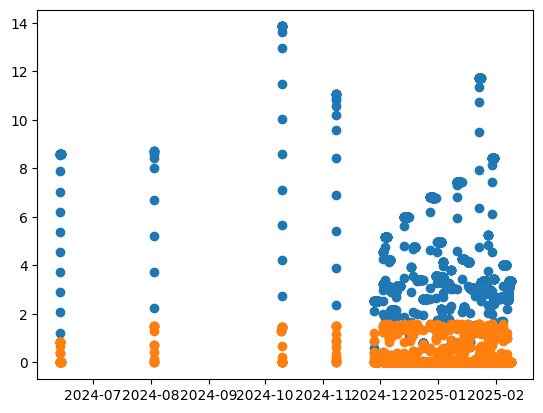

In [27]:
import seaborn as sns
from matplotlib import pyplot as plt
plt.scatter(pd.to_datetime(df_fifteen_min_data_port1_culmulative.stationTime).values, 
         df_fifteen_min_data_port1_culmulative.energyConsumed.values.astype(float))
# df_fifteen_min_data_port1.plot()

plt.scatter(pd.to_datetime(df_fifteen_min_data_port1_delta.stationTime).values, 
         df_fifteen_min_data_port1_delta.energyConsumed.values.astype(float))


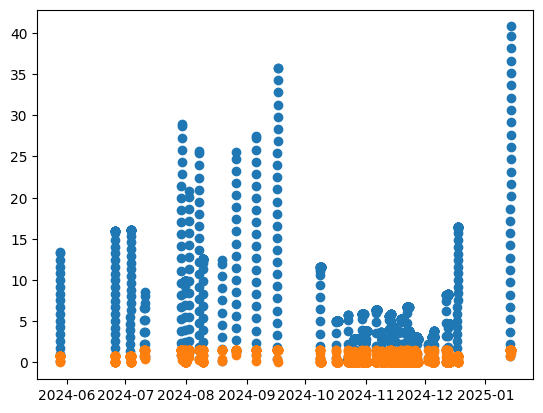

In [28]:
import seaborn as sns
from matplotlib import pyplot as plt
plt.scatter(pd.to_datetime(df_fifteen_min_data_port2_culmulative.stationTime).values, 
         df_fifteen_min_data_port2_culmulative.energyConsumed.values.astype(float))
# df_fifteen_min_data_port1.plot()

plt.scatter(pd.to_datetime(df_fifteen_min_data_port2_delta.stationTime).values, 
         df_fifteen_min_data_port2_delta.energyConsumed.values.astype(float))


In [1]:
# shedLoad experiment

In [ ]:
response_station = client.service.shedLoad(searchQuery)